#### This notebook reproduces figure 2 in "Age-related vulnerability greatly amplifies the risk of uncompensable heat" by Kong et al.

In [8]:
"""
import python packages
please install required packages before running this notebook
"""
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
%config InlineBackend.figure_format = "retina"

In [10]:
# directory to data; you might want to change it to your own directory
path='../data/'

"""
global number of population exposed to at least 180 or 540 hours of uncompensable heat annually
for the young, middle-aged and elderly.
for 15 climate models under 1-4°C warming
based on age-specific thresholds
population is derived following SSP2 scenario. It depends on climate model and warming level because different climate models reach the same warming level in different years
"""
exposed_pop=xr.open_dataset(path+'Global_exposed_population_by_age_groups.nc').pop

# same as above but applying the young adult thresholds to all age groups 
exposed_pop_younglimits=xr.open_dataset(path+'Global_exposed_population_by_age_groups_yong_limits.nc').pop

# global population of different age groups
pop=xr.open_dataset(path+'Global_population_by_age_groups.nc').pop


In [32]:
# create colormap
colors=np.array([
    [8,48,107],
    [8,81,156],
    [33,113,181],
    [66,146,198],
    [107,174,214],
    [251,106,74],
    [239,59,44],
    [203,24,29],
    [165,15,21],
    [103,0,13],
])
cmap=mpl.colors.ListedColormap(colors/255.)

In [33]:
def exposed_pop_num(duration,data):
    """
    calculate the number (in billion) of total, young, middle-aged, and old population exposed to at least 180 or 540 hours of uncompensable heat annually
    duration: 180 hours (month) and 540 hours (season)
    data: exposed population (exposed_pop or exposed_pop_younglimits)
    """
    y_tot=data.sum('age').sel(duration=duration)/1e9 # total exposed population in billion
    y_young=data.sel(age='young').sel(duration=duration)/1e9 # total exposed young population in billion
    y_middle=data.sel(age='middle-aged').sel(duration=duration)/1e9 # total exposed middle-aged population in billion
    y_old=data.sel(age='old').sel(duration=duration)/1e9 # total exposed elderly population in billion    
    return (y_tot,y_young,y_middle,y_old)

def exposed_pop_percent(duration,data):
    """
    calculate the percentage (%) of total, young, middle-aged, and old population exposed to at least 180 or 540 hours of uncompensable heat annually
    duration: 180 hours (month) and 540 hours (season)d
    data: exposed population (exposed_pop or exposed_pop_younglimits)
    """
    y_tot=data.sum('age').sel(duration=duration)/pop.sum('age')*100 # the percent of total population exposed
    y_young=data.sel(age='young').sel(duration=duration)/pop.sel(age='young')*100 # the percent of young population exposed
    y_middle=data.sel(age='middle-aged').sel(duration=duration)/pop.sel(age='middle-aged')*100 # the percent of middle-aged population exposed
    y_old=data.sel(age='old').sel(duration=duration)/pop.sel(age='old')*100 # the percent of old population exposed
    return (y_tot,y_young,y_middle,y_old)
   

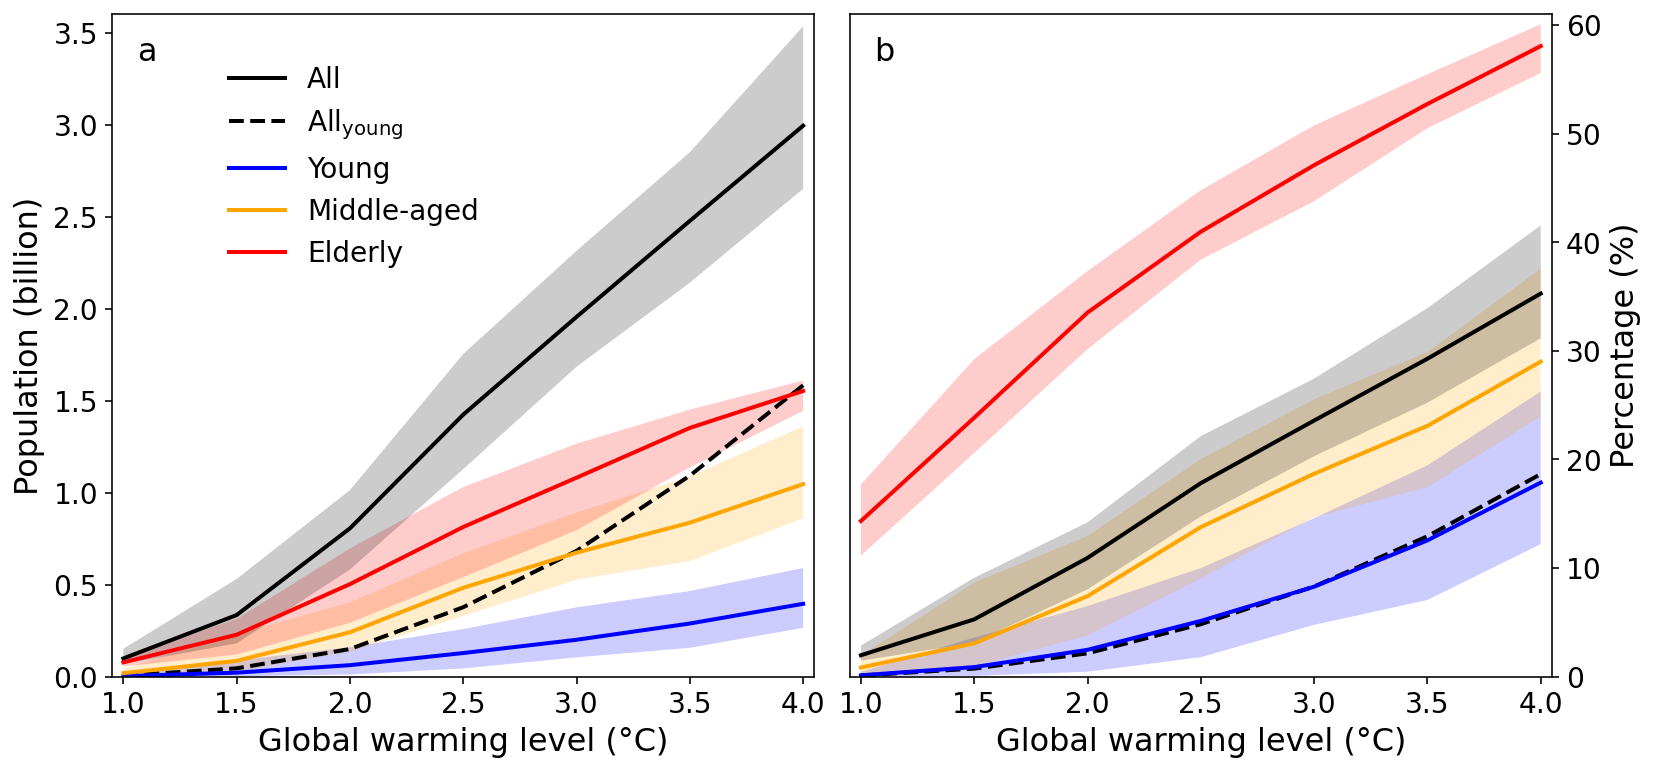

In [34]:
fig = plt.figure(figsize=(10,4.6))
ax1 = fig.add_subplot(121)
ax2 = fig.add_subplot(122)

Xs=[1,1.5,2,2.5,3,3.5,4] # set X variable to be global warming levels

# calculate global number of total, young, middle-aged and elderly population exposed to at least 180 hours of uncompensable heat annually
(exposed_pop_num_tot,exposed_pop_num_young, exposed_pop_num_middle, exposed_pop_num_old)=exposed_pop_num('month',exposed_pop)
# same as above but applying young adult limits to all age groups
(exposed_pop_num_tot_younglimits,exposed_pop_num_young_younglimits, exposed_pop_num_middle_younglimits, exposed_pop_num_old_younglimits)=exposed_pop_num('month',exposed_pop_younglimits)

ax1.plot(Xs,exposed_pop_num_tot.mean('model'),linewidth=2,color='k',label='All')
ax1.plot(Xs,exposed_pop_num_tot_younglimits.mean('model'),linewidth=2,color='k',label=r'$\mathrm{All}_{\mathrm{young}}$',linestyle='dashed')
ax1.plot(Xs,exposed_pop_num_young.mean('model'),linewidth=2,color='blue',label='Young')
ax1.plot(Xs,exposed_pop_num_middle.mean('model'),linewidth=2,color='orange',label='Middle-aged')
ax1.plot(Xs,exposed_pop_num_old.mean('model'),linewidth=2,color='red',label='Elderly')


# shading represent the 5th-95th percentile inter-model spread
ax1.fill_between(Xs,
                 exposed_pop_num_young.quantile(0.05,dim='model'),
                 exposed_pop_num_young.quantile(0.95,dim='model'),
                 color='blue',alpha=0.2,
                edgecolor='none')
ax1.fill_between(Xs,
                 exposed_pop_num_middle.quantile(0.05,dim='model'),
                 exposed_pop_num_middle.quantile(0.95,dim='model'),
                 color='orange',alpha=0.2,
                edgecolor='none')
ax1.fill_between(Xs,
                 exposed_pop_num_old.quantile(0.05,dim='model'),
                 exposed_pop_num_old.quantile(0.95,dim='model'),
                 color='red',alpha=0.2,
                edgecolor='none')
ax1.fill_between(Xs,
                 exposed_pop_num_tot.quantile(0.05,dim='model'),
                 exposed_pop_num_tot.quantile(0.95,dim='model'),
                 color='k',alpha=0.2,
                edgecolor='none')

# calculate global percent of total, young, middle-aged and elderly population exposed to at least 180 hours of uncompensable heat annually
(exposed_pop_percent_tot,exposed_pop_percent_young, exposed_pop_percent_middle, exposed_pop_percent_old)=exposed_pop_percent('month',exposed_pop)
# same as above but applying young adult limits to all age groups
(exposed_pop_percent_tot_younglimits,exposed_pop_percent_young_younglimits, exposed_pop_percent_middle_younglimits, exposed_pop_percent_old_younglimits)=exposed_pop_percent('month',exposed_pop_younglimits)

ax2.plot(Xs,exposed_pop_percent_tot.mean('model'),linewidth=2,color='k')
ax2.plot(Xs,exposed_pop_percent_tot_younglimits.mean('model'),linewidth=2,color='k',linestyle='dashed')
ax2.plot(Xs,exposed_pop_percent_young.mean('model'),linewidth=2,color='blue')
ax2.plot(Xs,exposed_pop_percent_middle.mean('model'),linewidth=2,color='orange')
ax2.plot(Xs,exposed_pop_percent_old.mean('model'),linewidth=2,color='red')

# shading represent the 5th-95th percentile inter-model spread
ax2.fill_between(Xs,
                 exposed_pop_percent_young.quantile(0.05,dim='model'),
                 exposed_pop_percent_young.quantile(0.95,dim='model'),
                 color='blue',alpha=0.2,
                edgecolor='none')
ax2.fill_between(Xs,
                 exposed_pop_percent_middle.quantile(0.05,dim='model'),
                 exposed_pop_percent_middle.quantile(0.95,dim='model'),
                 color='orange',alpha=0.2,
                edgecolor='none')
ax2.fill_between(Xs,
                 exposed_pop_percent_old.quantile(0.05,dim='model'),
                 exposed_pop_percent_old.quantile(0.95,dim='model'),
                 color='red',alpha=0.2,
                edgecolor='none')
ax2.fill_between(Xs,
                 exposed_pop_percent_tot.quantile(0.05,dim='model'),
                 exposed_pop_percent_tot.quantile(0.95,dim='model'),
                 color='k',alpha=0.2,
                edgecolor='none')

annots=['a','b']
anno_opts = dict(xy=(0.05, 0.93), xycoords='axes fraction',va='baseline', ha='center')
j=0
for ax in [ax1,ax2]:
    ax.tick_params(axis='both', labelsize=14)
    ax.annotate(annots[j], **anno_opts,fontsize=16)  
    ax.set_xlim(0.95,4.05)
    j+=1
ax1.set_ylabel('Population (billion)',fontsize=16)
ax2.set_ylabel('Percentage (%)',fontsize=16)
ax1.set_xlabel('Global warming level (°C)',fontsize=16)
ax2.set_xlabel('Global warming level (°C)',fontsize=16)

ax1.legend(fontsize=14,frameon=False,loc=(0.15,0.6))

ax1.set_ylim([0,3.6])
ax2.set_ylim([0,61])

ax2.yaxis.tick_right()             # Moves ticks to the right
ax2.yaxis.set_label_position("right")  # Moves y-axis label to the right

fig.subplots_adjust(bottom=0, left=0,right=1, top=1,hspace=0.18,wspace=0.05)


**Figure 2**: The global number (a) and percentage (b) of young (blue), middle-aged (orange), elderly (red), and total populations (black) exposed to at least 180 hours of UHS annually under 1–4°C of
global warming relative to the preindustrial period. Shading indicates the 5th–95th percentile intermodel spread within the CMIP6 ensemble. Black dashed curves represent total exposed populations
when applying the young adult threshold to all age groups.